In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

In [2]:
df_final = pd.read_parquet("data/ready_to_train/CREDIT_df_final_80_feats_20250627.parquet")

In [3]:
categorical_cols = [
    'CustomerSex',
    'MCC Category',
    # 'POSMode',
    # 'CardProductGrouped',
    # 'CurrencyCodeGroup'
]
numerical_cols = [
    col for col in df_final.columns if col not in (categorical_cols + ['Confirmed','Transaction Datetime'])
]

In [4]:
top_numerical_cols = [
    'AvgDurationSinceFirstTrnxToCurrentMCCL30D',
    'TxnCountToPOSModeL15min',
    'RatioTxnCountToPOSModeL30DL15min',
    'CntUnique_CardNo_by_currencyCode_L30D',
    'RatioTxnCountL30DL15min',
    'RatioCntUnique_CardNo_by_currencyCodeL30DL15min',
    'Transaction Amount', # Channel
    'CntUnique_MCC_by_CardNo_L15M',
    'time_diff',
    'RatioCntUnique_MCC_by_CardNoL30DL15min',
    'TxnCount_L15M',
    'RatioTxnCount_to_countryCodeL30DL15min',
    'RatioTxnCount_to_MCCL30DL15min',
    'RatioSum_Amt_to_MCCL30DL15min',
    'TxnCount_to_countryCode_L15M',
    'Max_Amt_to_MCC_L30D',
    'AvgDurationSinceFirstTrnxToCurrentMCCL15min',
    'TotalTrxAmount10Mi', # TSCF
    'IsTop10HighRiskMCCLast30D',
    # 'RatioAvgDurationSinceFirstTrnxToCurrentMCCL30DL15min',
    # 'RatioSum_Amt_to_countryCodeL30DL15min',
    # 'Sum_Amt_to_MCC_L30D',
    # 'AvgDurationSinceFirstTrnxToCurrentCountryCodeL30D',
    # 'TotalTrxAmount15Mi',
    # 'CntUnique_CardNo_by_MCC_L30D'
]

In [5]:
len(top_numerical_cols + categorical_cols)

21

In [6]:
set(top_numerical_cols + categorical_cols)

{'AvgDurationSinceFirstTrnxToCurrentMCCL15min',
 'AvgDurationSinceFirstTrnxToCurrentMCCL30D',
 'CntUnique_CardNo_by_currencyCode_L30D',
 'CntUnique_MCC_by_CardNo_L15M',
 'CustomerSex',
 'IsTop10HighRiskMCCLast30D',
 'MCC Category',
 'Max_Amt_to_MCC_L30D',
 'RatioCntUnique_CardNo_by_currencyCodeL30DL15min',
 'RatioCntUnique_MCC_by_CardNoL30DL15min',
 'RatioSum_Amt_to_MCCL30DL15min',
 'RatioTxnCountL30DL15min',
 'RatioTxnCountToPOSModeL30DL15min',
 'RatioTxnCount_to_MCCL30DL15min',
 'RatioTxnCount_to_countryCodeL30DL15min',
 'TotalTrxAmount10Mi',
 'Transaction Amount',
 'TxnCountToPOSModeL15min',
 'TxnCount_L15M',
 'TxnCount_to_countryCode_L15M',
 'time_diff'}

In [7]:
df_final = df_final[['Confirmed','Transaction Datetime'] + top_numerical_cols + categorical_cols]

# Rename Column

In [8]:
renamed_column_map = {
    'AvgDurationSinceFirstTrnxToCurrentMCCL15min': 'AvgTimeFirstTxnToCurrentMCCL15min',
    'AvgDurationSinceFirstTrnxToCurrentMCCL30D': 'AvgTimeFirstTxnToCurrentMCCL30D',
    'CntUnique_CardNo_by_currencyCode_L30D': 'CntUniqueCardNoByCurrencyCodeL30D',
    'CntUnique_MCC_by_CardNo_L15M': 'CntUniqueMCCByCardNoL15min',
    'MCC Category': 'MCCCategory',
    'Max_Amt_to_MCC_L30D': 'MaxAmtToMCCL30D',
    'RatioAvgDurationSinceFirstTrnxToCurrentMCCL30DL15min': 'RatioAvgTimeFirstTxnToCurrentMCCL30DL15min',
    'RatioCntUnique_CardNo_by_currencyCodeL30DL15min': 'RatioCntUniqueCardNoByCurrencyCodeL30DL15min',
    'RatioCntUnique_MCC_by_CardNoL30DL15min': 'RatioCntUniqueMCCByCardNoL30DL15min',
    'RatioSum_Amt_to_MCCL30DL15min': 'RatioSumAmtToMCCL30DL15min',
    'RatioTxnCount_to_MCCL30DL15min': 'RatioTxnCountToMCCL30DL15min',
    'RatioTxnCount_to_countryCodeL30DL15min': 'RatioTxnCountToCountryCodeL30DL15min',
    'Transaction Amount': 'TransactionAmount',
    'TxnCount_L15M': 'TxnCountL15min',
    'TxnCount_to_countryCode_L15M': 'TxnCountToCountryCodeL15min',
    'time_diff': 'TxnTimeDifference',
}
df_final = df_final.rename(columns=renamed_column_map)

# Model Train

In [15]:
# df_final.to_parquet("data/ready_to_train/df_credit_final_21_feats_20250702.parquet")
df_final = pd.read_parquet("data/ready_to_train/df_credit_final_21_feats_20250702.parquet")

In [16]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1398828 entries, 1040632159 to 1143967558
Data columns (total 23 columns):
 #   Column                                        Non-Null Count    Dtype         
---  ------                                        --------------    -----         
 0   Confirmed                                     1398828 non-null  bool          
 1   Transaction Datetime                          1398828 non-null  datetime64[ns]
 2   AvgTimeFirstTxnToCurrentMCCL30D               1398828 non-null  float64       
 3   TxnCountToPOSModeL15min                       1268246 non-null  float64       
 4   RatioTxnCountToPOSModeL30DL15min              1398828 non-null  float64       
 5   CntUniqueCardNoByCurrencyCodeL30D             1394356 non-null  float64       
 6   RatioTxnCountL30DL15min                       1398828 non-null  float64       
 7   RatioCntUniqueCardNoByCurrencyCodeL30DL15min  1398828 non-null  float64       
 8   TransactionAmount                  

In [27]:
5.538110e+05

553811.0

In [25]:
(1398828 - 1387919)/1398828

0.007798671459250173

In [19]:
df_final[['TransactionAmount']].describe()

,TransactionAmount
count,1.387919e+06
mean,1.855082e+06
std,1.441096e+07
min,0.000000e+00
25%,4.050000e+04
50%,1.460000e+05
75%,5.538110e+05
max,2.519598e+09


In [23]:
df_final.TransactionAmount.isna()

Transaction Serial No
1040632159    False
1040632192    False
1040632255    False
1040632283    False
1040633185    False
              ...  
1143963114    False
1143965471    False
1143965646    False
1143966563    False
1143967558    False
Name: TransactionAmount, Length: 1398828, dtype: bool

In [3]:
# setup pipeline
pipeline_rf = ModelPipeline(
    model_type="random_forest",
    random_state=42
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest


In [3]:
# setup pipeline
pipeline_xgb = ModelPipeline(
    model_type="xgboost",
    random_state=42
)

Initializing ModelPipeline with model type: xgboost
Retrieving model instance for type: xgboost


In [4]:
split_date = "2025-05-01"
df_splits = pipeline_rf.split_data_by_date(
    df=df_final,
    date_column="Transaction Datetime",
    split_date=split_date
)

Splitting data by date (pre-preprocessing)...
Train samples: 1197282, Test samples: 201546
Data splitting complete.


In [6]:
# prepare TRAIN data
target_col = "Confirmed"
X, y = pipeline_rf.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    encoding_type="OneHot",
    is_apply_log=False,
    is_impute_median=False,
    is_training=True
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'CustomerSex': ['0', '1', '2', '__missing__']
  Fitted categories for column 'MCCCategory': ['AIRLINES, AIR CARRIERS', 'ASSOCIATIONS/ORGANIZATIONS', 'BUSINESS/PROFESSIONAL/MISCELLANEOUS SERVICES', 'CAR RENTAL AGENCIES', 'CLOTHING/SHOES/ACCESSORIES/UNIFORMS/RETAIL STORES/BUYING AND SELLING SERVICES', 'EDUCATIONAL SERVICES', 'ELECTRONIC AND TECHNICAL SERVICES', 'ENTERTAINMENT/THEATER/DANCE STUDIOS', 'FINANCIAL SERVICES', 'FURNISHINGS/APPLIANCES/MAINTENANCE/HOME', 'GROCERY STORES/PHARMACIES/FOOD SERVICES/RESTAURANTS', 'HEALTHCARE/CHILD SERVICES', 'LODGING — HOTELS, MOTELS, RESORTS', 'OTHER', 'PERSONAL SERVICES', 'TRAVEL/TRANSPORTATION/GAS AND FUEL SERVICES', '__missing__']
CategoryManager fitting complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying

In [7]:
# split data
X_train, X_test, y_train, y_test = pipeline_rf.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


## Randomized

In [8]:
from src.imbalance_learn import ImbalancedSampler

# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm='RandomOverSampler',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using RandomOverSampler: Counter({False: 831875, True: 166375})


## SMOTE

In [9]:
# OverSampling
smote_sampler = ImbalancedSampler(
    algorithm='SMOTE',
    sampler_type='upsample',
    target_ratio=0.2, # 7%
    random_state=1234
)

X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({False: 831875, True: 6222})
Resampled dataset shape using SMOTE: Counter({False: 831875, True: 166375})


## Train XGB

In [18]:
# build and train
pipeline_xgb.build_pipeline()
pipeline_xgb.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...


C:\Users\Administrator\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:59:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.


In [19]:
# Evaluate
test_results = pipeline_xgb.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9943
AUC: 0.9875
PR AUC: 0.7969
Precision: 0.5844
Recall: 0.8009

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00    356518
        True       0.58      0.80      0.68      2667

    accuracy                           0.99    359185
   macro avg       0.79      0.90      0.84    359185
weighted avg       1.00      0.99      0.99    359185



In [20]:
base_xgb = pipeline_xgb.get_model()

Returning trained model...


In [21]:
import pickle

filepath = "model/credit/base_xgb_ros_38_feats_20250801_v2.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_xgb, f)

## Train ROS

In [34]:
# build and train
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [35]:
base_rf_ros = pipeline.get_model()

Returning trained model...


In [36]:
import pickle

filepath = "model/credit/base_rf_ros_38_feats_20250702.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf_ros, f)

In [37]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9742
AUC: 0.9902
PR AUC: 0.6981
Precision: 0.2106
Recall: 0.9003

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.97      0.99    356518
        True       0.21      0.90      0.34      2667

    accuracy                           0.97    359185
   macro avg       0.60      0.94      0.66    359185
weighted avg       0.99      0.97      0.98    359185



## Train SMOTE

In [10]:
# build and train
pipeline_rf.build_pipeline()
pipeline_rf.train(X_train_smote, y_train_smote, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [12]:
base_rf_smote = pipeline_rf.get_model()

Returning trained model...


In [13]:
# Evaluate
test_results_smote = pipeline_rf.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9792
AUC: 0.9889
PR AUC: 0.6647
Precision: 0.2465
Recall: 0.8759

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.98      0.99    356518
        True       0.25      0.88      0.38      2667

    accuracy                           0.98    359185
   macro avg       0.62      0.93      0.69    359185
weighted avg       0.99      0.98      0.98    359185



In [14]:
import pickle

base_rf_smote = pipeline_rf.get_model()
filepath = "model/credit/base_rf_smote_38_feats_20250801.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf_smote, f)

Returning trained model...


# BackTesting

In [22]:
df_credit_mix = pd.read_parquet("data/base/df_credit_clean_dec24_may25.parquet")
trx_id_list = list(df_credit_mix[df_credit_mix.Confirmed.isin([0,1])]['Transaction Serial No'])
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [23]:
X_oos, y_oos = pipeline_xgb.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    encoding_type="Direct",
    is_apply_log=False,
    is_impute_median=False,
    is_training=False
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
  Transformed column 'CustomerSex' to numerical codes.
  Transformed column 'MCCCategory' to numerical codes.
CategoryManager transformation complete.
Identified numerical columns for imputation: ['AvgTimeFirstTxnToCurrentMCCL30D', 'TxnCountToPOSModeL15min', 'RatioTxnCountToPOSModeL30DL15min', 'CntUniqueCardNoByCurrencyCodeL30D', 'RatioTxnCountL30DL15min', 'RatioCntUniqueCardNoByCurrencyCodeL30DL15min', 'TransactionAmount', 'CntUniqueMCCByCardNoL15min', 'TxnTimeDifference', 'RatioCntUniqueMCCByCardNoL30DL15min', 'TxnCountL15min', 'RatioTxnCountToCountryCodeL30DL15min', 'RatioTxnCountToMCCL30DL15min', 'RatioSumAmtToMCCL30DL15min', 'TxnCountToCountryCodeL15min', 'MaxAmtToMCCL30D', 'AvgTimeFirstTxnToCurrentMCCL15min', 'TotalTrxAmount10Mi', 'IsTop10HighRiskMCCLast30D']
Identified categorical columns (encoded): [

In [24]:
# Evaluate ALL trx (base RF ROS)
oos_results = pipeline_xgb.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9936
AUC: 0.9519
PR AUC: 0.5431
Precision: 0.5799
Recall: 0.5034

Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00    200054
        True       0.58      0.50      0.54      1492

    accuracy                           0.99    201546
   macro avg       0.79      0.75      0.77    201546
weighted avg       0.99      0.99      0.99    201546



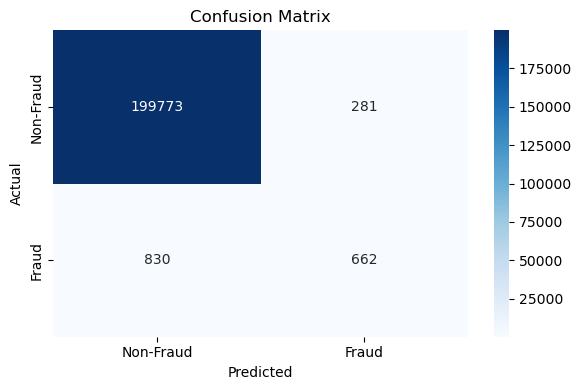

Recall/True Positive Rate: The model got 44.37% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 70.2% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.14% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [46]:
from src.utils import plot_confusion_matrix

y_oos_prob = base_rf_ros.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.902)

## SMOTE Backtest

In [23]:
# SMOTE RF
oos_results_smote = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9851
AUC: 0.9816
PR AUC: 0.5169
Precision: 0.2911
Recall: 0.7078

Classification Report:
               precision    recall  f1-score   support

       False       1.00      0.99      0.99    200054
        True       0.29      0.71      0.41      1492

    accuracy                           0.99    201546
   macro avg       0.64      0.85      0.70    201546
weighted avg       0.99      0.99      0.99    201546



# Feature Importance

In [19]:
len(top_25_numerical_cols + selected_categorical_cols), len(X.columns)

(23, 47)